# Sesión 4: Random Forest (Bosques Aleatorios)
## Ensemble Learning - La Unión Hace la Fuerza

**Objetivo**: Aprender cómo combinar múltiples árboles de decisión para crear un modelo más robusto y preciso.

**Duración**: ~60 minutos

**Pregunta**: ¿Qué pasa si en lugar de confiar en UN árbol, combinamos las opiniones de 100 árboles?

## 1. Configuración y Carga de Datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Librerías de machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Cargar dataset
data_path = Path('../data/datos_liga_futbol.csv')
df = pd.read_csv(data_path)

print(f"✓ Dataset cargado: {df.shape[0]} partidos")
print(f"✓ Librerías importadas")

✓ Dataset cargado: 280 partidos
✓ Librerías importadas


## 2. Preprocesamiento (Feature Engineering)

In [2]:
# Crear features (mismo que sesiones anteriores)
df['Diferencia_Habilidad'] = df['Habilidad_Local'] - df['Habilidad_Visitante']
df['Diferencia_Racha'] = df['Racha_Local'] - df['Racha_Visitante']
df['Ratio_Habilidad'] = df['Habilidad_Local'] / df['Habilidad_Visitante']

# Seleccionar features
features = [
    'Habilidad_Local',
    'Habilidad_Visitante',
    'Racha_Local',
    'Racha_Visitante',
    'Diferencia_Habilidad',
    'Diferencia_Racha',
    'Ratio_Habilidad'
]

X = df[features]
y = df['Resultado']

# Split train/test (MISMO random_state para comparación justa)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("✓ Features creados")
print(f"\nTrain set: {len(X_train)} partidos")
print(f"Test set: {len(X_test)} partidos")

✓ Features creados

Train set: 224 partidos
Test set: 56 partidos


## 3. ¿Qué es un Random Forest?

### 🌲🌲🌲 Concepto de Ensemble Learning

**Random Forest** = "Bosque Aleatorio" = Muchos árboles de decisión trabajando juntos

### 💡 Analogía: Consultar a Múltiples Expertos

Imagina que quieres predecir quién ganará un partido:

**Enfoque 1** (Árbol de Decisión):
- Preguntas a UN experto
- Si se equivoca, pierdes

**Enfoque 2** (Random Forest):
- Preguntas a 100 expertos diferentes
- Cada uno tiene su propia opinión
- Tomas la respuesta de la MAYORÍA
- Más robusto: si algunos se equivocan, la mayoría corrige

### 🎲 ¿Cómo se crean árboles "diferentes"?

1. **Bootstrap Sampling**: Cada árbol entrena con una muestra aleatoria de datos (con reemplazo)
2. **Feature Randomness**: Cada división solo considera un subconjunto aleatorio de features
3. **Votación**: La clase final es la que más árboles predicen

### ✅ Ventajas de Random Forest

- ✓ Reduce overfitting (vs árbol individual)
- ✓ Más preciso y robusto
- ✓ Maneja bien datos con ruido
- ✓ Feature importance confiable
- ✗ Menos interpretable que un árbol
- ✗ Más lento de entrenar

## 4. Entrenamiento del Random Forest

In [3]:
# Crear y entrenar Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,  # Número de árboles en el bosque
    max_depth=10,  # Profundidad máxima de cada árbol
    min_samples_split=5,  # Mínimo de muestras para dividir
    min_samples_leaf=2,  # Mínimo de muestras en hojas
    random_state=42,
    n_jobs=-1  # Usar todos los CPU cores disponibles
)

# Entrenar
print("⏳ Entrenando Random Forest con 100 árboles...")
random_forest.fit(X_train, y_train)
print("✓ Random Forest entrenado")

print(f"\nCONFIGURACIÓN DEL BOSQUE:")
print(f"  Número de árboles: {random_forest.n_estimators}")
print(f"  Profundidad máxima: {random_forest.max_depth}")
print(f"  Features por split: {random_forest.max_features}")
print(f"  Clases aprendidas: {random_forest.classes_}")

⏳ Entrenando Random Forest con 100 árboles...
✓ Random Forest entrenado

CONFIGURACIÓN DEL BOSQUE:
  Número de árboles: 100
  Profundidad máxima: 10
  Features por split: sqrt
  Clases aprendidas: ['Empate' 'Victoria Local' 'Victoria Visitante']


## 5. Evaluación del Random Forest

RESULTADOS - RANDOM FOREST:

Accuracy en TRAIN: 0.732 (73.2%)
Accuracy en TEST:  0.446 (44.6%)
Diferencia (Train-Test): 0.286


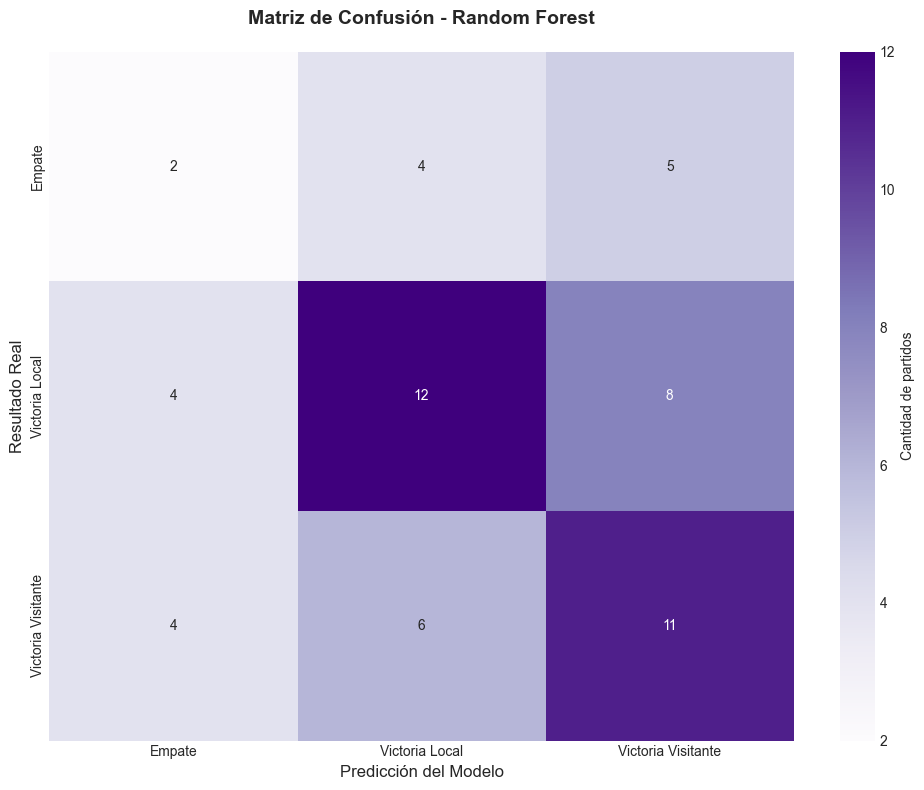


REPORTE DETALLADO:
                    precision    recall  f1-score   support

            Empate       0.20      0.18      0.19        11
    Victoria Local       0.55      0.50      0.52        24
Victoria Visitante       0.46      0.52      0.49        21

          accuracy                           0.45        56
         macro avg       0.40      0.40      0.40        56
      weighted avg       0.44      0.45      0.44        56



In [4]:
# Predicciones
y_train_pred_rf = random_forest.predict(X_train)
y_test_pred_rf = random_forest.predict(X_test)

# Accuracy
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("RESULTADOS - RANDOM FOREST:")
print(f"\nAccuracy en TRAIN: {train_accuracy_rf:.3f} ({train_accuracy_rf*100:.1f}%)")
print(f"Accuracy en TEST:  {test_accuracy_rf:.3f} ({test_accuracy_rf*100:.1f}%)")
print(f"Diferencia (Train-Test): {(train_accuracy_rf - test_accuracy_rf):.3f}")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=random_forest.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', 
            xticklabels=random_forest.classes_, 
            yticklabels=random_forest.classes_,
            cbar_kws={'label': 'Cantidad de partidos'})
plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Resultado Real', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("\nREPORTE DETALLADO:")
print("="*60)
print(classification_report(y_test, y_test_pred_rf, target_names=random_forest.classes_))

## 6. Comparación con Modelos Anteriores

Comparemos Random Forest con los modelos que ya hemos entrenado.

⏳ Entrenando modelos anteriores para comparación...

COMPARACIÓN DE LOS 3 MODELOS:
             Modelo  Accuracy Train  Accuracy Test  Diferencia
Regresión Logística        0.513393       0.392857    0.120536
  Árbol de Decisión        0.562500       0.482143    0.080357
      Random Forest        0.732143       0.446429    0.285714


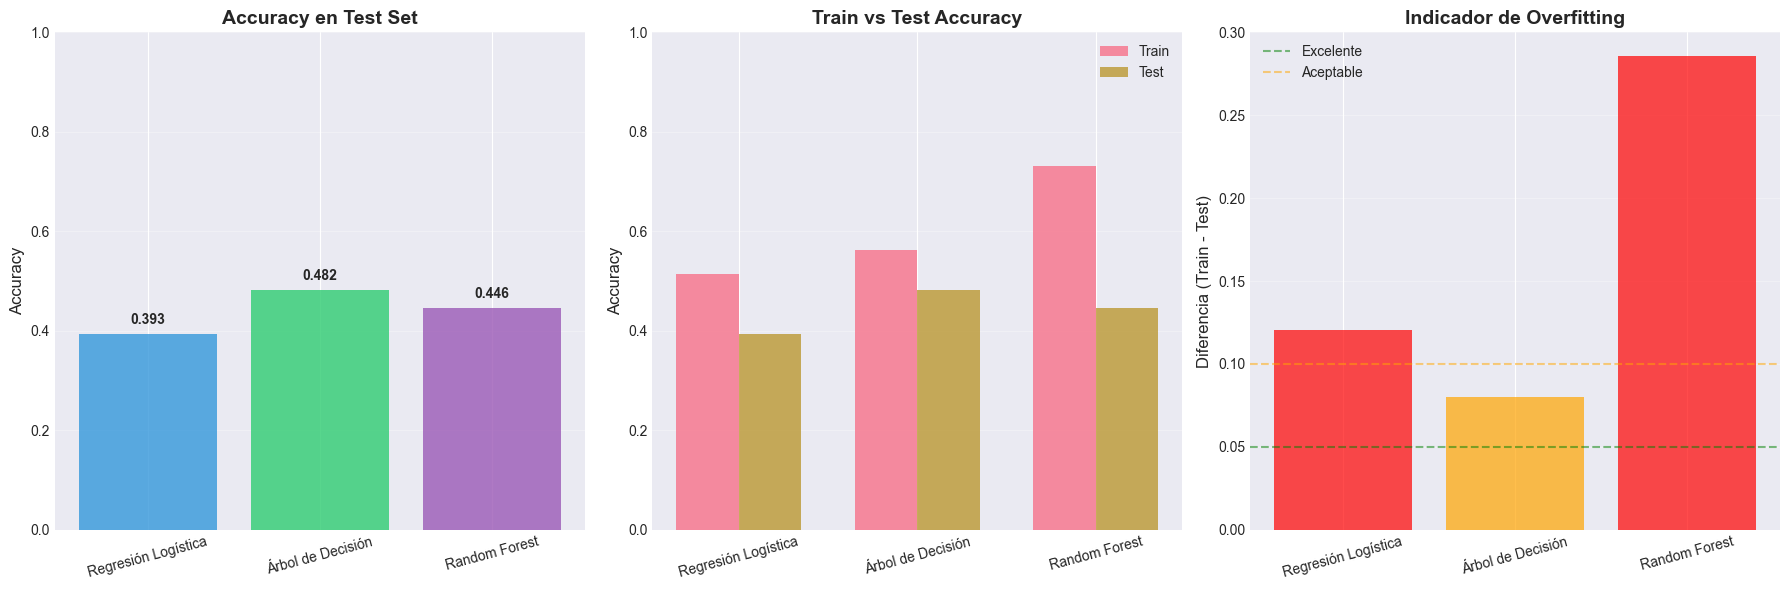


💡 ANÁLISIS:

  🏆 MEJOR MODELO: Árbol de Decisión
     Accuracy en Test: 0.482 (48.2%)

  🎯 OVERFITTING:
     Regresión Logística: ⚠️ Moderado (diff=0.121)
     Árbol de Decisión: ✓ Bajo (diff=0.080)
     Random Forest: ⚠️ Moderado (diff=0.286)


In [5]:
# Entrenar modelos anteriores para comparación
print("⏳ Entrenando modelos anteriores para comparación...\n")

# Regresión Logística
logistic = LogisticRegression(max_iter=1000, random_state=42)
logistic.fit(X_train, y_train)
test_acc_log = accuracy_score(y_test, logistic.predict(X_test))
train_acc_log = accuracy_score(y_train, logistic.predict(X_train))

# Árbol de Decisión
tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
tree.fit(X_train, y_train)
test_acc_tree = accuracy_score(y_test, tree.predict(X_test))
train_acc_tree = accuracy_score(y_train, tree.predict(X_train))

# Tabla comparativa
comparacion = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Accuracy Train': train_acc_log,
        'Accuracy Test': test_acc_log,
        'Diferencia': train_acc_log - test_acc_log
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Accuracy Train': train_acc_tree,
        'Accuracy Test': test_acc_tree,
        'Diferencia': train_acc_tree - test_acc_tree
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy Train': train_accuracy_rf,
        'Accuracy Test': test_accuracy_rf,
        'Diferencia': train_accuracy_rf - test_accuracy_rf
    }
])

print("COMPARACIÓN DE LOS 3 MODELOS:")
print("="*80)
print(comparacion.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Accuracy en Test
colors_test = ['#3498db', '#2ecc71', '#9b59b6']
axes[0].bar(comparacion['Modelo'], comparacion['Accuracy Test'], color=colors_test, alpha=0.8)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy en Test Set', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)
# Añadir valores sobre las barras
for i, v in enumerate(comparacion['Accuracy Test']):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

# Gráfico 2: Train vs Test
x = np.arange(len(comparacion))
width = 0.35
axes[1].bar(x - width/2, comparacion['Accuracy Train'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, comparacion['Accuracy Test'], width, label='Test', alpha=0.8)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparacion['Modelo'], rotation=15)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Gráfico 3: Overfitting (Diferencia Train-Test)
colors_over = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' 
               for x in comparacion['Diferencia']]
axes[2].bar(comparacion['Modelo'], comparacion['Diferencia'], color=colors_over, alpha=0.7)
axes[2].set_ylabel('Diferencia (Train - Test)', fontsize=12)
axes[2].set_title('Indicador de Overfitting', fontsize=14, fontweight='bold')
axes[2].axhline(0.05, color='green', linestyle='--', alpha=0.5, label='Excelente')
axes[2].axhline(0.1, color='orange', linestyle='--', alpha=0.5, label='Aceptable')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Análisis
print("\n💡 ANÁLISIS:")
mejor_modelo_idx = comparacion['Accuracy Test'].idxmax()
mejor_modelo = comparacion.loc[mejor_modelo_idx, 'Modelo']
mejor_accuracy = comparacion.loc[mejor_modelo_idx, 'Accuracy Test']

print(f"\n  🏆 MEJOR MODELO: {mejor_modelo}")
print(f"     Accuracy en Test: {mejor_accuracy:.3f} ({mejor_accuracy*100:.1f}%)")

if mejor_modelo == 'Random Forest':
    mejora_vs_log = (test_accuracy_rf - test_acc_log) * 100
    mejora_vs_tree = (test_accuracy_rf - test_acc_tree) * 100
    print(f"\n  📈 MEJORAS:")
    print(f"     vs Regresión Logística: +{mejora_vs_log:.1f} puntos porcentuales")
    print(f"     vs Árbol de Decisión: +{mejora_vs_tree:.1f} puntos porcentuales")

print(f"\n  🎯 OVERFITTING:")
for _, row in comparacion.iterrows():
    if row['Diferencia'] < 0.05:
        nivel = "✓ Muy bajo"
    elif row['Diferencia'] < 0.1:
        nivel = "✓ Bajo"
    else:
        nivel = "⚠️ Moderado"
    print(f"     {row['Modelo']}: {nivel} (diff={row['Diferencia']:.3f})")

## 7. Feature Importance en Random Forest

Una de las ventajas del Random Forest es que proporciona importancias de features más robustas.

IMPORTANCIA DE FEATURES - RANDOM FOREST:
             Feature  Importancia
     Ratio_Habilidad     0.210616
Diferencia_Habilidad     0.171910
     Habilidad_Local     0.170631
 Habilidad_Visitante     0.149281
    Diferencia_Racha     0.126863
         Racha_Local     0.094045
     Racha_Visitante     0.076654


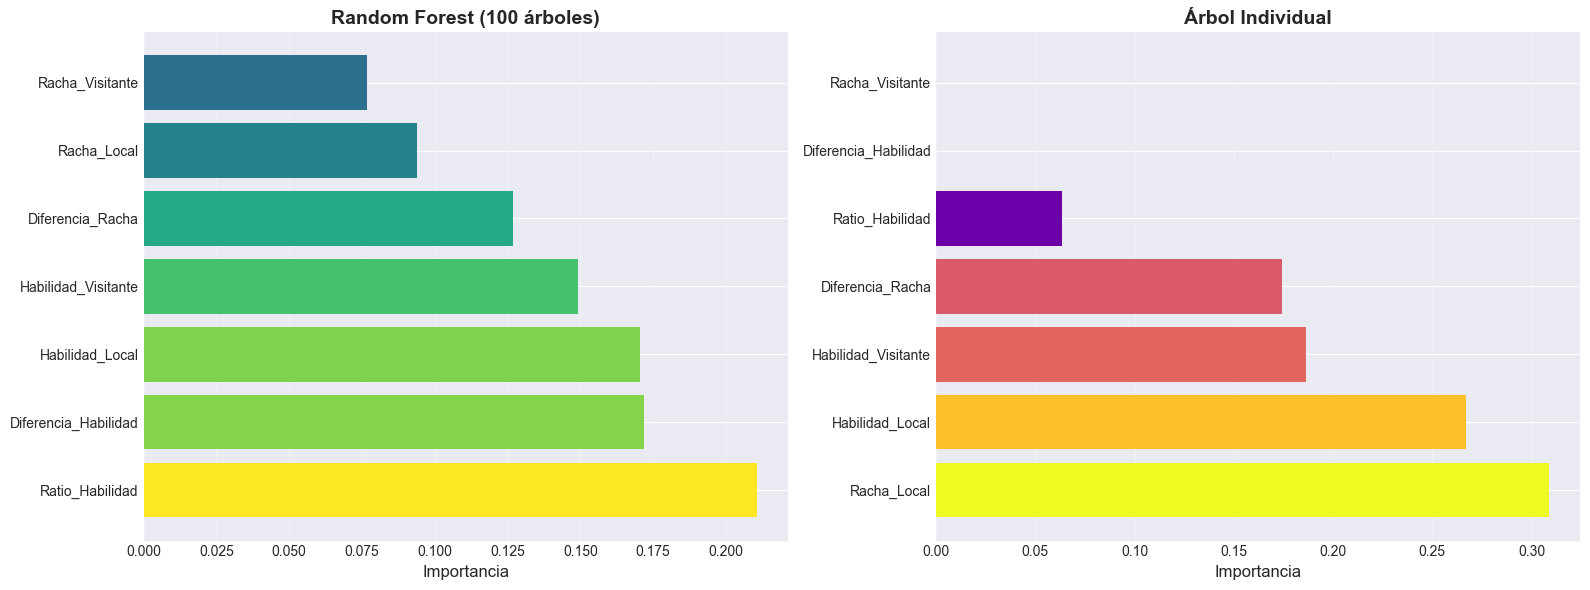


💡 INTERPRETACIÓN:

  TOP 3 FEATURES (Random Forest):
    1. Ratio_Habilidad: 21.1%
    2. Diferencia_Habilidad: 17.2%
    3. Habilidad_Local: 17.1%

  🔍 DIFERENCIAS CON ÁRBOL INDIVIDUAL:
     Random Forest promedia las importancias de 100 árboles
     → Estimación más ROBUSTA y CONFIABLE
     → Menos sensible a outliers o ruido en los datos


In [6]:
# Obtener importancias
importances_rf = pd.DataFrame({
    'Feature': features,
    'Importancia': random_forest.feature_importances_
}).sort_values('Importancia', ascending=False)

print("IMPORTANCIA DE FEATURES - RANDOM FOREST:")
print("="*50)
print(importances_rf.to_string(index=False))

# Comparar con árbol individual
importances_tree = pd.DataFrame({
    'Feature': features,
    'Importancia': tree.feature_importances_
}).sort_values('Importancia', ascending=False)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
colors_rf = plt.cm.viridis(importances_rf['Importancia'] / importances_rf['Importancia'].max())
axes[0].barh(importances_rf['Feature'], importances_rf['Importancia'], color=colors_rf)
axes[0].set_xlabel('Importancia', fontsize=12)
axes[0].set_title('Random Forest (100 árboles)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Árbol Individual
colors_tree = plt.cm.plasma(importances_tree['Importancia'] / importances_tree['Importancia'].max())
axes[1].barh(importances_tree['Feature'], importances_tree['Importancia'], color=colors_tree)
axes[1].set_xlabel('Importancia', fontsize=12)
axes[1].set_title('Árbol Individual', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN:")
print(f"\n  TOP 3 FEATURES (Random Forest):")
for i in range(min(3, len(importances_rf))):
    feat = importances_rf.iloc[i]
    print(f"    {i+1}. {feat['Feature']}: {feat['Importancia']*100:.1f}%")

print(f"\n  🔍 DIFERENCIAS CON ÁRBOL INDIVIDUAL:")
print(f"     Random Forest promedia las importancias de 100 árboles")
print(f"     → Estimación más ROBUSTA y CONFIABLE")
print(f"     → Menos sensible a outliers o ruido en los datos")

## 8. Análisis de Confianza en las Predicciones

Random Forest proporciona probabilidades más calibradas que un árbol individual.

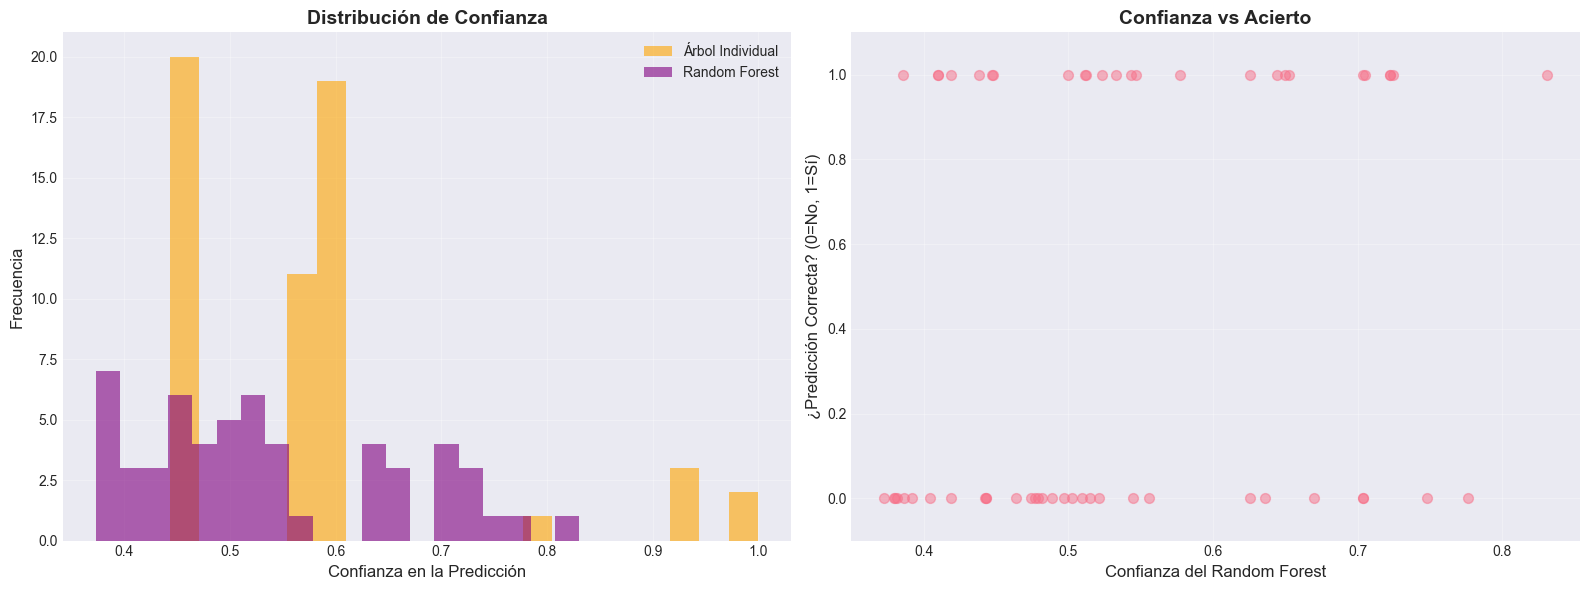

ESTADÍSTICAS DE CONFIANZA:

Random Forest:
  Confianza promedio: 0.536
  Confianza mínima: 0.373
  Confianza máxima: 0.831

Árbol Individual:
  Confianza promedio: 0.571
  Confianza mínima: 0.443
  Confianza máxima: 1.000

💡 OBSERVACIÓN:
  El árbol individual tiende a ser MÁS CONFIADO (a veces demasiado)
  Random Forest es más CAUTELOSO y REALISTA en sus probabilidades


In [7]:
# Obtener probabilidades
probs_rf = random_forest.predict_proba(X_test)
probs_tree = tree.predict_proba(X_test)

# Confianza = probabilidad máxima
confidence_rf = probs_rf.max(axis=1)
confidence_tree = probs_tree.max(axis=1)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de confianza
axes[0].hist(confidence_tree, bins=20, alpha=0.6, label='Árbol Individual', color='orange')
axes[0].hist(confidence_rf, bins=20, alpha=0.6, label='Random Forest', color='purple')
axes[0].set_xlabel('Confianza en la Predicción', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Confianza', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot: Confianza vs Acierto
aciertos_rf = (y_test_pred_rf == y_test).astype(int)
axes[1].scatter(confidence_rf, aciertos_rf, alpha=0.5, s=50)
axes[1].set_xlabel('Confianza del Random Forest', fontsize=12)
axes[1].set_ylabel('¿Predicción Correcta? (0=No, 1=Sí)', fontsize=12)
axes[1].set_title('Confianza vs Acierto', fontsize=14, fontweight='bold')
axes[1].set_ylim([-0.1, 1.1])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ESTADÍSTICAS DE CONFIANZA:")
print("="*60)
print(f"\nRandom Forest:")
print(f"  Confianza promedio: {confidence_rf.mean():.3f}")
print(f"  Confianza mínima: {confidence_rf.min():.3f}")
print(f"  Confianza máxima: {confidence_rf.max():.3f}")

print(f"\nÁrbol Individual:")
print(f"  Confianza promedio: {confidence_tree.mean():.3f}")
print(f"  Confianza mínima: {confidence_tree.min():.3f}")
print(f"  Confianza máxima: {confidence_tree.max():.3f}")

print(f"\n💡 OBSERVACIÓN:")
if confidence_tree.max() > confidence_rf.max():
    print(f"  El árbol individual tiende a ser MÁS CONFIADO (a veces demasiado)")
    print(f"  Random Forest es más CAUTELOSO y REALISTA en sus probabilidades")

## 9. Experimento: ¿Cuántos Árboles Necesitamos?

Probemos con diferentes números de árboles para ver cómo afecta el desempeño.

🔬 EXPERIMENTANDO con diferentes números de árboles...

    1 árboles → Train: 0.670, Test: 0.357
    5 árboles → Train: 0.759, Test: 0.411
   10 árboles → Train: 0.808, Test: 0.500
   25 árboles → Train: 0.830, Test: 0.411
   50 árboles → Train: 0.839, Test: 0.464
  100 árboles → Train: 0.848, Test: 0.446
  200 árboles → Train: 0.848, Test: 0.464


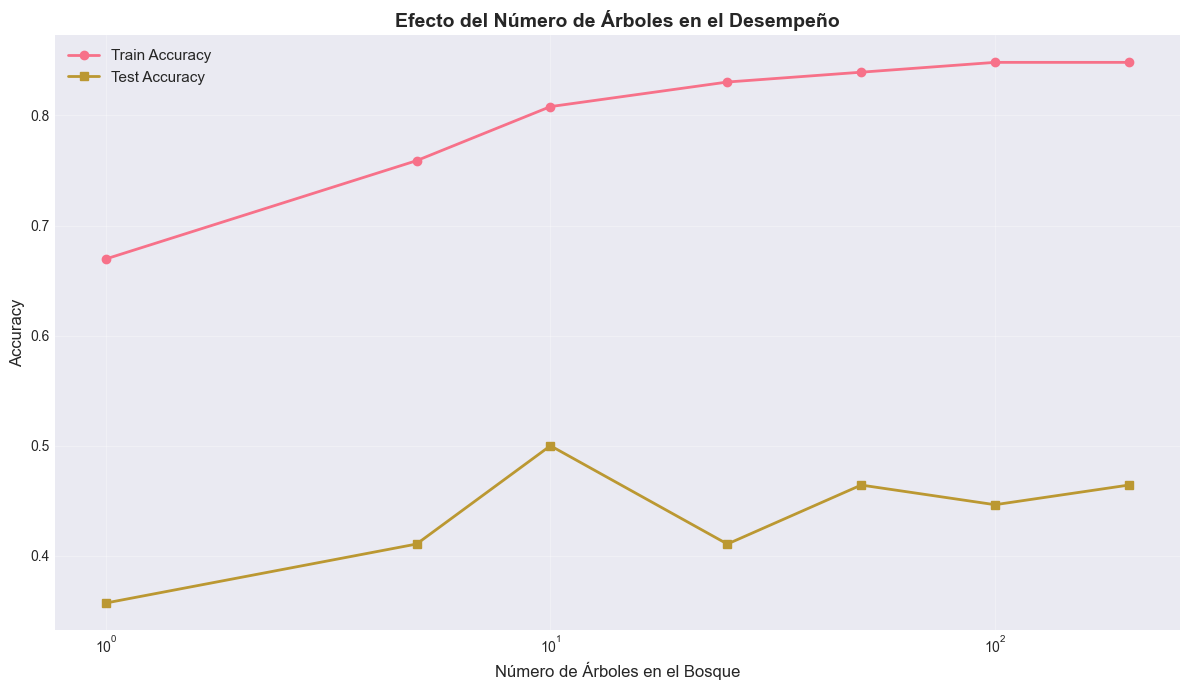


💡 CONCLUSIONES:
  - Con 1 árbol: es simplemente un árbol de decisión
  - Al aumentar árboles: mejora el accuracy y reduce overfitting
  - Después de ~50-100 árboles: las mejoras son marginales
  - Trade-off: Más árboles = mejor desempeño pero más lento


In [8]:
# Probar con diferentes números de árboles
n_trees_list = [1, 5, 10, 25, 50, 100, 200]
train_scores = []
test_scores = []

print("🔬 EXPERIMENTANDO con diferentes números de árboles...\n")

for n_trees in n_trees_list:
    rf_temp = RandomForestClassifier(n_estimators=n_trees, max_depth=10, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
    test_acc = accuracy_score(y_test, rf_temp.predict(X_test))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    print(f"  {n_trees:3d} árboles → Train: {train_acc:.3f}, Test: {test_acc:.3f}")

# Visualización
plt.figure(figsize=(12, 7))
plt.plot(n_trees_list, train_scores, marker='o', label='Train Accuracy', linewidth=2)
plt.plot(n_trees_list, test_scores, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Número de Árboles en el Bosque', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Efecto del Número de Árboles en el Desempeño', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xscale('log')  # Escala logarítmica para ver mejor la tendencia
plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES:")
print(f"  - Con 1 árbol: es simplemente un árbol de decisión")
print(f"  - Al aumentar árboles: mejora el accuracy y reduce overfitting")
print(f"  - Después de ~50-100 árboles: las mejoras son marginales")
print(f"  - Trade-off: Más árboles = mejor desempeño pero más lento")

## 10. Ejemplos de Predicciones

In [9]:
# Seleccionar 5 ejemplos del test set
np.random.seed(42)
ejemplos_indices = np.random.choice(X_test.index, size=5, replace=False)
ejemplos = df.loc[ejemplos_indices]

# Predicciones con los 3 modelos
X_ejemplos = ejemplos[features]
pred_log = logistic.predict(X_ejemplos)
pred_tree = tree.predict(X_ejemplos)
pred_rf = random_forest.predict(X_ejemplos)
probs_rf_ejemplos = random_forest.predict_proba(X_ejemplos)

print("COMPARACIÓN DE PREDICCIONES - 5 PARTIDOS:")
print("="*80)

for i, idx in enumerate(ejemplos_indices, 1):
    partido = ejemplos.loc[idx]
    
    print(f"\n📊 PARTIDO {i}:")
    print(f"   {partido['Equipo_Local']} vs {partido['Equipo_Visitante']}")
    print(f"   Habilidades: {partido['Habilidad_Local']} vs {partido['Habilidad_Visitante']}")
    print(f"   Rachas: {partido['Racha_Local']} vs {partido['Racha_Visitante']}")
    
    print(f"\n   Resultado Real: {partido['Resultado']}")
    print(f"\n   PREDICCIONES:")
    print(f"     Logística:       {pred_log[i-1]}")
    print(f"     Árbol:           {pred_tree[i-1]}")
    print(f"     Random Forest:   {pred_rf[i-1]} {'✓' if pred_rf[i-1] == partido['Resultado'] else '✗'}")
    
    print(f"\n   PROBABILIDADES (Random Forest):")
    for j, clase in enumerate(random_forest.classes_):
        print(f"      {clase}: {probs_rf_ejemplos[i-1][j]*100:.1f}%")
    print("-" * 80)

COMPARACIÓN DE PREDICCIONES - 5 PARTIDOS:

📊 PARTIDO 1:
   Cóndores United vs Pumas CF
   Habilidades: 60 vs 68
   Rachas: 0 vs 0

   Resultado Real: Victoria Local

   PREDICCIONES:
     Logística:       Victoria Visitante
     Árbol:           Victoria Visitante
     Random Forest:   Victoria Visitante ✗

   PROBABILIDADES (Random Forest):
      Empate: 9.7%
      Victoria Local: 19.9%
      Victoria Visitante: 70.4%
--------------------------------------------------------------------------------

📊 PARTIDO 2:
   Cóndores United vs Águilas United
   Habilidades: 60 vs 82
   Rachas: 0 vs 1

   Resultado Real: Victoria Visitante

   PREDICCIONES:
     Logística:       Victoria Visitante
     Árbol:           Victoria Visitante
     Random Forest:   Victoria Visitante ✓

   PROBABILIDADES (Random Forest):
      Empate: 19.0%
      Victoria Local: 8.6%
      Victoria Visitante: 72.5%
--------------------------------------------------------------------------------

📊 PARTIDO 3:
   Leones 

## 11. Resumen y Conclusiones

### 🌲 ¿Qué Aprendimos sobre Random Forest?

1. **Ensemble Learning**:
   - Combinar múltiples modelos débiles → modelo fuerte
   - "Wisdom of the crowd" (sabiduría de las masas)
   - Reduce overfitting y mejora generalización

2. **Ventajas del Random Forest**:
   - ✓ Más preciso que un árbol individual
   - ✓ Robusto ante ruido y outliers
   - ✓ Feature importance confiable
   - ✓ Pocas hiperparámetros críticos
   - ✗ Menos interpretable
   - ✗ Más costoso computacionalmente

3. **Hiperparámetros importantes**:
   - `n_estimators`: Número de árboles (100-200 suele ser bueno)
   - `max_depth`: Profundidad de cada árbol
   - `min_samples_split` y `min_samples_leaf`: Control de overfitting

### 📊 Resultados hasta Ahora

In [10]:
# Resumen final
resumen_final = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Accuracy Test': f"{test_acc_log:.3f}",
        'Tipo': 'Lineal',
        'Interpretabilidad': 'Media',
        'Velocidad': 'Rápida'
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Accuracy Test': f"{test_acc_tree:.3f}",
        'Tipo': 'No lineal',
        'Interpretabilidad': 'Alta',
        'Velocidad': 'Rápida'
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy Test': f"{test_accuracy_rf:.3f}",
        'Tipo': 'Ensemble',
        'Interpretabilidad': 'Baja',
        'Velocidad': 'Media'
    }
])

print("="*80)
print("RESUMEN COMPARATIVO - SESIONES 2, 3 Y 4")
print("="*80)
print(resumen_final.to_string(index=False))

print(f"\n💾 Métricas guardadas para comparación final")
print(f"\n🎯 PRÓXIMO PASO: Sesión 5 - XGBoost")
print("   ¿Podemos mejorar aún más con Gradient Boosting?")
print("   Spoiler: XGBoost es uno de los algoritmos más ganadores en competencias")
print("="*80)

RESUMEN COMPARATIVO - SESIONES 2, 3 Y 4
             Modelo Accuracy Test      Tipo Interpretabilidad Velocidad
Regresión Logística         0.393    Lineal             Media    Rápida
  Árbol de Decisión         0.482 No lineal              Alta    Rápida
      Random Forest         0.446  Ensemble              Baja     Media

💾 Métricas guardadas para comparación final

🎯 PRÓXIMO PASO: Sesión 5 - XGBoost
   ¿Podemos mejorar aún más con Gradient Boosting?
   Spoiler: XGBoost es uno de los algoritmos más ganadores en competencias
